# Modelo No Supervisado

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv("accidentes_limpios.csv")

variables = [
    'HORA',
    'MES',
    'DIA_SEMANA',
    'TOTAL_VICTIMAS_24H',
    'TOTAL_VEHICULOS',
    'CONDICION_METEO',
    'CONDICION_ILUMINACION',
    'CONDICION_FIRME',
    'TRAZADO_PLANTA',
    'HAY_NIEBLA',
    'TIPO_VIA',
    'TIPO_ACCIDENTE'
]

X = df[variables]

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Buenas praticas para ver que cluster se acomoda mas al proyecto
# El mejor K es el que tiene el score más alto.

for k in range(2, 11):
  modelo = KMeans(
      n_clusters=k,
      random_state=42
  )

  clusters = modelo.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, clusters)

  print(f"K={k} -> {score:.4f}")

K=2 -> 0.2621
K=3 -> 0.1894
K=4 -> 0.1729
K=5 -> 0.2055
K=6 -> 0.2003
K=7 -> 0.2027
K=8 -> 0.1255
K=9 -> 0.1338
K=10 -> 0.1401


In [4]:
# Crear modelo K-Means
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

# Entrenar modelo
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# Validar con Silhouette Score
score = silhouette_score(X_scaled, clusters)
print(f'Silhouette Score Final: {score:.4f}')

Silhouette Score Final: 0.2621


In [5]:
print(df['Cluster'].value_counts())
print("\n")
print(df.groupby('Cluster')[variables].mean())

Cluster
1    89962
0    12033
Name: count, dtype: int64


              HORA       MES  DIA_SEMANA  TOTAL_VICTIMAS_24H  TOTAL_VEHICULOS  \
Cluster                                                                         
0        13.497216  6.231779    3.932768            1.341062         1.539433   
1        13.740602  6.616427    3.865321            1.337120         1.754141   

         CONDICION_METEO  CONDICION_ILUMINACION  CONDICION_FIRME  \
Cluster                                                            
0               3.266766               2.248068         4.010471   
1               1.054456               1.857629         1.053667   

         TRAZADO_PLANTA  HAY_NIEBLA  TIPO_VIA  TIPO_ACCIDENTE  
Cluster                                                        
0            528.591457    0.051442  7.725588        8.887725  
1            647.262133    0.076288  8.554868        6.907005  


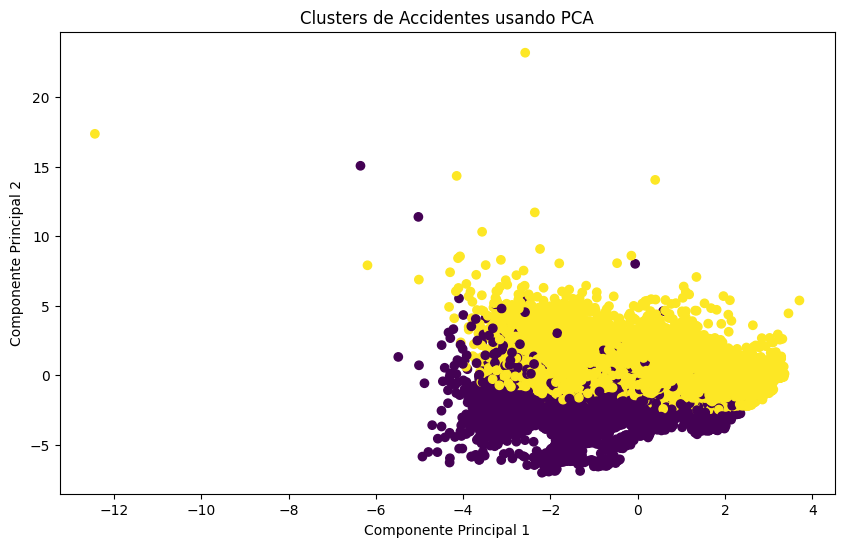

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title('Clusters de Accidentes usando PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# Modelo Supervisado

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df['ACCIDENTE_GRAVE'] = (
    df['TOTAL_VICTIMAS_24H'] >= 2
).astype(int)

variables = [
    'HORA',
    'MES',
    'DIA_SEMANA',
    'TOTAL_VEHICULOS',
    'CONDICION_METEO',
    'CONDICION_ILUMINACION',
    'CONDICION_FIRME',
    'TRAZADO_PLANTA',
    'HAY_NIEBLA',
    'TIPO_VIA',
    'TIPO_ACCIDENTE'
]

X = df[variables]
y = df['ACCIDENTE_GRAVE']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# MODELO 1 - Arbol De Desicisión

In [8]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)

print('=== Decision Tree ===\n')

print('Accuracy:',
      accuracy_score(y_test, y_pred_tree))
print('Precision:',
      precision_score(y_test, y_pred_tree))
print('Recall:',
      recall_score(y_test, y_pred_tree))
print('F1-Score:',
      f1_score(y_test, y_pred_tree))

=== Decision Tree ===

Accuracy: 0.71518211677043
Precision: 0.32182182182182184
Recall: 0.29320565435476514
F1-Score: 0.3068480076354092


In [9]:
print('\n Matriz de Confusión:\n')

print(confusion_matrix(y_test, y_pred_tree))


 Matriz de Confusión:

[[13303  2710]
 [ 3100  1286]]


In [10]:
print('\n Informe de clasificación:\n')
print(classification_report(y_test, y_pred_tree))


 Informe de clasificación:

              precision    recall  f1-score   support

           0       0.81      0.83      0.82     16013
           1       0.32      0.29      0.31      4386

    accuracy                           0.72     20399
   macro avg       0.57      0.56      0.56     20399
weighted avg       0.71      0.72      0.71     20399



# MODELO 2 - SVM

In [11]:
svm_model = SVC(
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print('=== SVM ===\n')

print('Accuracy:',
      accuracy_score(y_test, y_pred_svm))
print('Precision:',
      precision_score(y_test, y_pred_svm))
print('Recall:',
      recall_score(y_test, y_pred_svm))
print('F1-Score:',
      f1_score(y_test, y_pred_svm))

=== SVM ===

Accuracy: 0.7936173341830481
Precision: 0.6139896373056994
Recall: 0.10807113543091655
F1-Score: 0.18379216750678556


In [12]:
print('\n Matriz de Confusión:\n')

print(confusion_matrix(y_test, y_pred_svm))


 Matriz de Confusión:

[[15715   298]
 [ 3912   474]]


In [13]:
print('\n Informe de clasificación:\n')

print(classification_report(y_test, y_pred_svm))


 Informe de clasificación:

              precision    recall  f1-score   support

           0       0.80      0.98      0.88     16013
           1       0.61      0.11      0.18      4386

    accuracy                           0.79     20399
   macro avg       0.71      0.54      0.53     20399
weighted avg       0.76      0.79      0.73     20399



# Revisar el Overfitting y el Underfitting - Modelo de Arbol de Desición

In [14]:
print('Train Accuracy:',
      tree_model.score(X_train_scaled, y_train))
print('Test Accuracy:',
      tree_model.score(X_test_scaled, y_test))

Train Accuracy: 0.944837982254032
Test Accuracy: 0.71518211677043


# Revisar el Overfitting y el Underfitting - Modelo SVM

In [15]:
print('Train Accuracy:',
      svm_model.score(X_train_scaled, y_train))
print('Test Accuracy:',
      svm_model.score(X_test_scaled, y_test))

Train Accuracy: 0.79076180204912
Test Accuracy: 0.7936173341830481


# Optimización con GridSearchCV

### GRIDSEARCHCV — ÁRBOL DE DECISIÓN

In [22]:
from sklearn.model_selection import GridSearchCV

# Definir parámetros
parametros_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Crear GridSearchCV
grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42
    ),
    param_grid=parametros_tree,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

# Entrenar GridSearch
grid_tree.fit(X_train_scaled, y_train)

print('Mejores parámetros:\n')
print(grid_tree.best_params_)

print('\nMejor Score:\n')
print(grid_tree.best_score_)

Mejores parámetros:

{'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

Mejor Score:

0.2730575809476766


In [23]:
best_tree = grid_tree.best_estimator_
y_pred_best_tree = best_tree.predict(X_test_scaled)

print('\n=== Decision Tree Optimizado ===\n')

print('Accuracy:',
      accuracy_score(y_test, y_pred_best_tree))

print('Precision:',
      precision_score(y_test, y_pred_best_tree))

print('Recall:',
      recall_score(y_test, y_pred_best_tree))

print('F1-Score:',
      f1_score(y_test, y_pred_best_tree))


=== Decision Tree Optimizado ===

Accuracy: 0.7774400705916956
Precision: 0.4580152671755725
Recall: 0.19151846785225718
F1-Score: 0.27009646302250806


In [24]:
print('\n Matriz de Confusión:\n')

print(confusion_matrix(
    y_test,
    y_pred_best_tree
))


 Matriz de Confusión:

[[15019   994]
 [ 3546   840]]


In [25]:
print('\n Classification Report:\n')

print(classification_report(
    y_test,
    y_pred_best_tree
))


 Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.94      0.87     16013
           1       0.46      0.19      0.27      4386

    accuracy                           0.78     20399
   macro avg       0.63      0.56      0.57     20399
weighted avg       0.73      0.78      0.74     20399



# Optimización SVM — Limitación Computacional Documentada

### ¿Por qué no se optimizó el SVM con búsqueda de hiperparámetros?

El dataset `accidentes_limpios.csv` contiene aproximadamente **100.000 registros**.
El algoritmo SVM tiene complejidad computacional **O(n²) a O(n³)** respecto
al número de muestras, lo que lo hace inviable para búsquedas de hiperparámetros
exhaustivas o aleatorias en entornos con recursos de cómputo limitados.

Se verificaron y documentaron dos enfoques:

| Método | Resultado |
|--------|-----------|
| GridSearchCV | Superó 40 minutos sin converger |
| RandomizedSearchCV (n_iter=20, cv=3) | Superó 18 minutos sin converger |

**Decisión técnica justificada:** se mantiene el SVM con kernel RBF
y parámetros por defecto como modelo base de comparación.
Para datasets de esta magnitud, la literatura recomienda **LinearSVC**
o reducción del dataset mediante muestreo estratificado previo a la optimización.

In [39]:
svm_model = SVC(
    kernel='linear',
    C=1,
    random_state=42
)

# Entrenar modelo
svm_model.fit(X_train_scaled, y_train)


,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [40]:
# Predicciones
y_pred_svm = svm_model.predict(X_test_scaled)

# Métricas
print('=== SVM ===\n')

print('Accuracy:',
      accuracy_score(y_test, y_pred_svm))
print('Precision:',
      precision_score(y_test, y_pred_svm))
print('Recall:',
      recall_score(y_test, y_pred_svm))
print('F1-Score:',
      f1_score(y_test, y_pred_svm))


=== SVM ===

Accuracy: 0.7849894602676601
Precision: 0.0
Recall: 0.0
F1-Score: 0.0


c:\Users\dg886\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [41]:
print('\n Matriz de Confusión:\n')

print(confusion_matrix(
    y_test,
    y_pred_svm
))


 Matriz de Confusión:

[[16013     0]
 [ 4386     0]]


In [42]:
# Classification Report
print('\nClassification Report:\n')

print(classification_report(
    y_test,
    y_pred_svm
))


Classification Report:

              precision    recall  f1-score   support

           0       0.78      1.00      0.88     16013
           1       0.00      0.00      0.00      4386

    accuracy                           0.78     20399
   macro avg       0.39      0.50      0.44     20399
weighted avg       0.62      0.78      0.69     20399



c:\Users\dg886\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dg886\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dg886\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

# MATRIZ DE CONFUSIÓN — ÁRBOL OPTIMIZADO

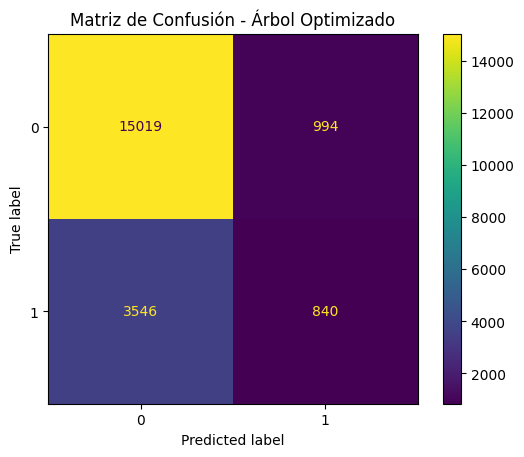

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_tree,
    X_test_scaled,
    y_test
)

plt.title('Matriz de Confusión - Árbol Optimizado')
plt.show()

# MATRIZ DE CONFUSIÓN — SVM 

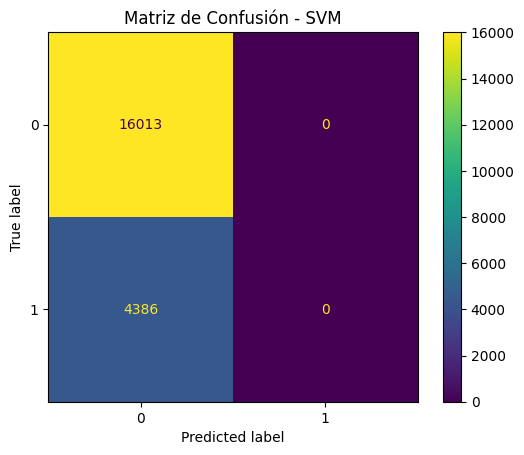

In [43]:
ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_scaled,
    y_test
)

plt.title('Matriz de Confusión - SVM')
plt.show()

# FEATURE IMPORTANCE — ÁRBOL

In [34]:
importancias = best_tree.feature_importances_

feature_importance = pd.DataFrame({

    'Variable': variables,

    'Importancia': importancias

})

feature_importance = feature_importance.sort_values(
    by='Importancia',
    ascending=False
)

print(feature_importance)

                 Variable  Importancia
3         TOTAL_VEHICULOS     0.188383
0                    HORA     0.149782
10         TIPO_ACCIDENTE     0.138059
1                     MES     0.126401
9                TIPO_VIA     0.125536
2              DIA_SEMANA     0.083239
5   CONDICION_ILUMINACION     0.054820
7          TRAZADO_PLANTA     0.043352
4         CONDICION_METEO     0.042780
6         CONDICION_FIRME     0.030789
8              HAY_NIEBLA     0.016858


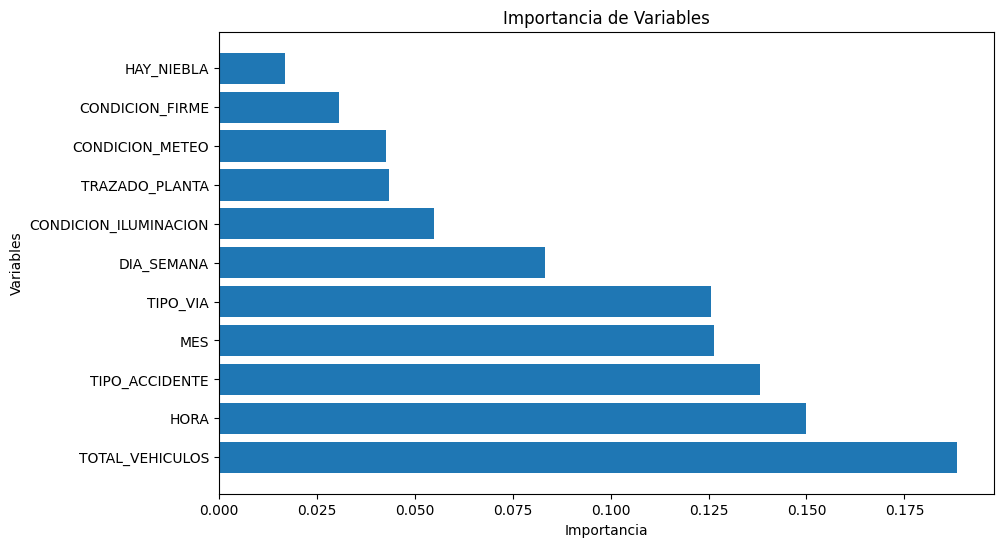

In [35]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Variable'],
    feature_importance['Importancia']
)
plt.title('Importancia de Variables')
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.show()

In [44]:
resultados = pd.DataFrame({

    'Modelo': [
        'Decision Tree',
        'Decision Tree Optimizado',
        'SVM'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_best_tree),
        accuracy_score(y_test, y_pred_svm)
    ],

    'Precision': [
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_best_tree),
        precision_score(y_test, y_pred_svm)
    ],

    'Recall': [
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_best_tree),
        recall_score(y_test, y_pred_svm)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_best_tree),
        f1_score(y_test, y_pred_svm)
    ]
})

print(resultados)

                     Modelo  Accuracy  Precision    Recall  F1-Score
0             Decision Tree  0.715182   0.321822  0.293206  0.306848
1  Decision Tree Optimizado  0.777440   0.458015  0.191518  0.270096
2                       SVM  0.784989   0.000000  0.000000  0.000000


c:\Users\dg886\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


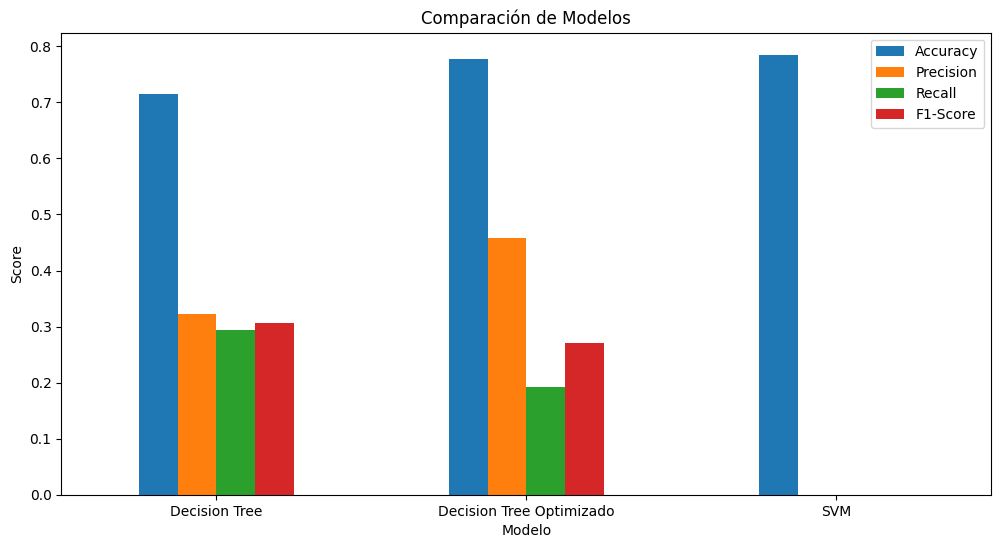

In [37]:
resultados.plot(
    x='Modelo',
    y=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    kind='bar',
    figsize=(12,6)
)

plt.title('Comparación de Modelos')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()